In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/artheon/pulse-2026-music-evolution-and-viral-analytics/Music_Evolution_2026_Pulse.csv


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/artheon/pulse-2026-music-evolution-and-viral-analytics/Music_Evolution_2026_Pulse.csv")
df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute,Vocal_Balance,Energy_Density,Vibe_Score,Viral_Potential_Index
0,0.975000,-12.550260,0.023500,0.358178,0.003424,0.225496,0.651890,264606.551066,0.765595,117.109723,0.003150,0.287894,0.552095,0.462136
1,0.513300,-1.616862,0.024072,0.513633,0.000001,0.176413,0.283309,206351.879142,0.613481,148.836001,-0.150584,0.094700,0.275487,0.356314
2,0.636704,-7.662865,0.024492,0.132557,0.166124,0.152315,0.628489,290156.180452,0.814531,128.698751,0.021346,0.034244,0.357336,0.416557
3,0.767151,-9.441020,0.066747,0.332356,0.196040,0.199684,0.501320,158079.704705,0.242119,72.913466,-0.117992,0.023652,0.528508,0.305117
4,0.625258,-1.605062,0.101830,0.160555,0.086590,0.027419,0.419884,257188.627463,0.575931,125.283749,-0.210277,0.333675,0.626095,0.483792


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RhythmScore                50000 non-null  float64
 1   AudioLoudness              50000 non-null  float64
 2   VocalContent               50000 non-null  float64
 3   AcousticQuality            50000 non-null  float64
 4   InstrumentalScore          50000 non-null  float64
 5   LivePerformanceLikelihood  50000 non-null  float64
 6   MoodScore                  50000 non-null  float64
 7   TrackDurationMs            50000 non-null  float64
 8   Energy                     50000 non-null  float64
 9   BeatsPerMinute             50000 non-null  float64
 10  Vocal_Balance              50000 non-null  float64
 11  Energy_Density             50000 non-null  float64
 12  Vibe_Score                 50000 non-null  float64
 13  Viral_Potential_Index      50000 non-null  flo

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute,Vocal_Balance,Energy_Density,Vibe_Score,Viral_Potential_Index
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,0.613879,-7.751244,0.083409,0.291456,0.112996,0.201979,0.551673,247782.846384,0.485005,118.236413,-0.055831,0.138020,0.363734,0.335264
std,0.153493,4.337001,0.044689,0.202844,0.116464,0.114148,0.204045,64961.695445,0.283955,26.615146,0.146399,0.083264,0.155222,0.116535
min,0.267311,-26.077279,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000200,46.836780,-0.554368,0.000050,0.006445,0.006155
25%,0.484574,-10.021115,0.038256,0.148165,0.004429,0.095422,0.458726,209141.367164,0.255325,98.135077,-0.177990,0.078900,0.253441,0.246917
50%,0.622407,-8.547457,0.088915,0.320630,0.078376,0.213215,0.547093,254585.044495,0.495518,115.158013,-0.031609,0.142203,0.348192,0.337685
75%,0.719481,-4.323856,0.108415,0.384426,0.166836,0.286553,0.694412,294652.827301,0.744601,139.656025,0.063579,0.179972,0.486449,0.423854
max,0.975000,-1.357000,0.248959,0.995000,0.577967,0.554708,0.978000,397292.154200,1.000000,201.415529,0.246858,0.594708,0.953550,0.727396


In [5]:
df = df.dropna()

In [6]:
df["tempo_energy_ratio"] = df["BeatsPerMinute"] / (df["Energy"] + 1e-5)
df["loudness_energy"] = df["AudioLoudness"] * df["Energy"]
df["vibe_density"] = df["Vibe_Score"] * df["Energy_Density"]

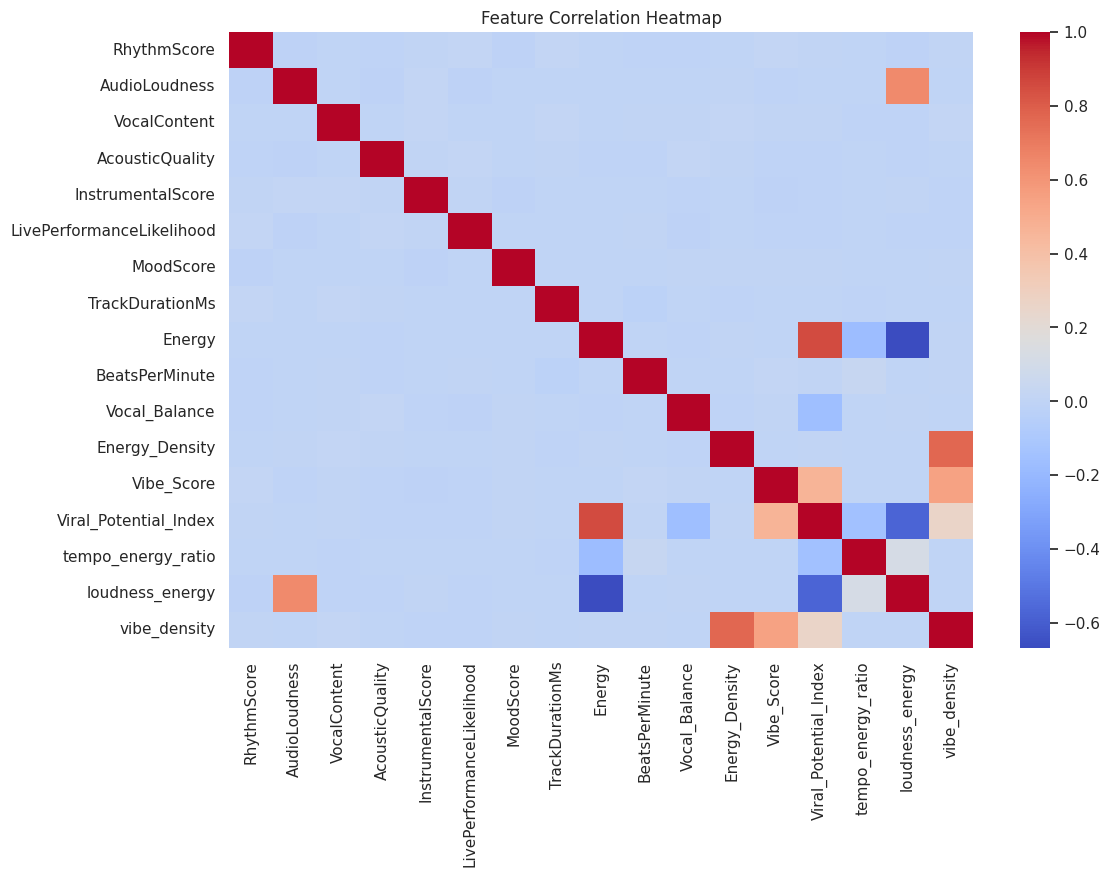

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

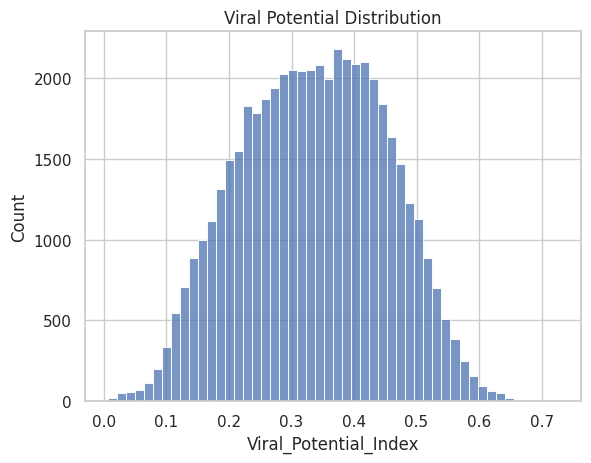

In [8]:
sns.histplot(df["Viral_Potential_Index"], bins=50)
plt.title("Viral Potential Distribution")
plt.show()

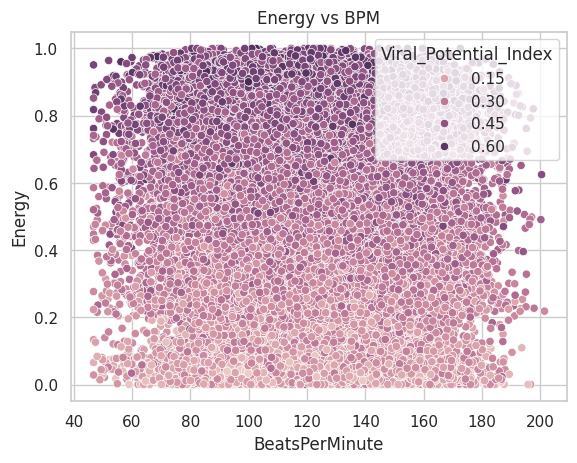

In [9]:
sns.scatterplot(x="BeatsPerMinute", y="Energy", hue="Viral_Potential_Index", data=df)
plt.title("Energy vs BPM")
plt.show()

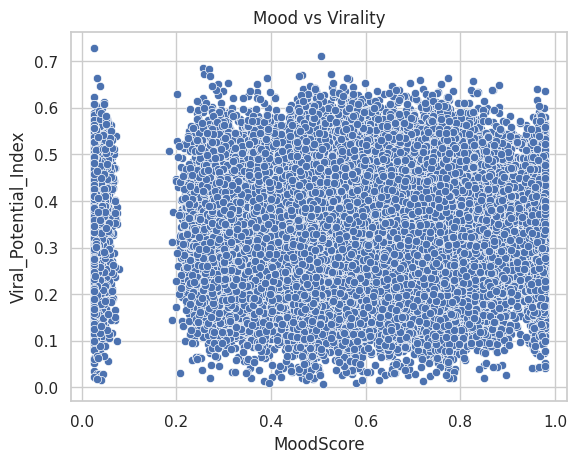

In [10]:
sns.scatterplot(x="MoodScore", y="Viral_Potential_Index", data=df)
plt.title("Mood vs Virality")
plt.show()

In [11]:
X = df.drop(columns=["Viral_Potential_Index"])
y = df["Viral_Potential_Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)

preds = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("RMSE:", rmse)

RMSE: 0.0030572877291677953


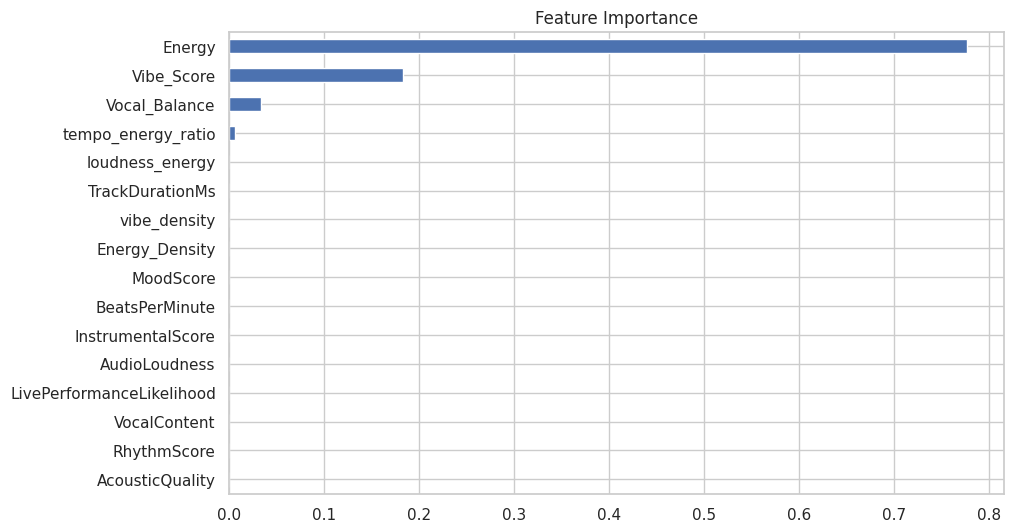

In [12]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance")
plt.show()

In [13]:
df["viral"] = (df["Viral_Potential_Index"] > 0.7).astype(int)

X = df.drop(columns=["Viral_Potential_Index", "viral"])
y = df["viral"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 1.0


In [14]:
features = df.drop(columns=["Viral_Potential_Index", "viral"])

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled)

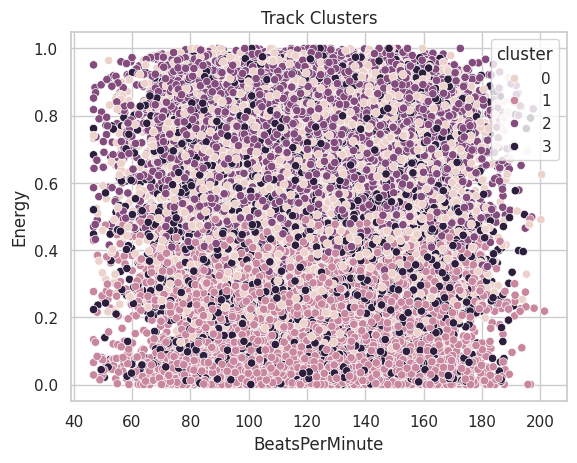

In [15]:
sns.scatterplot(
    x="BeatsPerMinute",
    y="Energy",
    hue="cluster",
    data=df
)
plt.title("Track Clusters")
plt.show()

In [16]:
high_viral = df[df["Viral_Potential_Index"] > 0.7]

print("Average Features of Viral Tracks:\n")
print(high_viral.mean())

Average Features of Viral Tracks:

RhythmScore                       0.791769
AudioLoudness                    -5.681478
VocalContent                      0.024943
AcousticQuality                   0.147838
InstrumentalScore                 0.167727
LivePerformanceLikelihood         0.024300
MoodScore                         0.265662
TrackDurationMs              311591.621565
Energy                            0.903178
BeatsPerMinute                  125.371395
Vocal_Balance                    -0.097888
Energy_Density                    0.054416
Vibe_Score                        0.915525
Viral_Potential_Index             0.719378
tempo_energy_ratio              139.999457
loudness_energy                  -4.889896
vibe_density                      0.049933
viral                             1.000000
cluster                           2.500000
dtype: float64


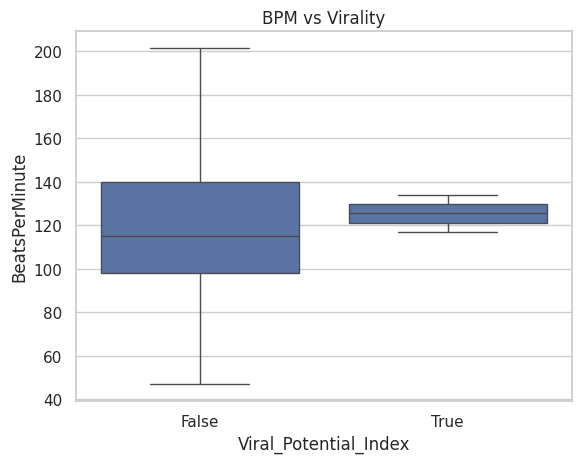

In [17]:
sns.boxplot(x=df["Viral_Potential_Index"] > 0.7, y=df["BeatsPerMinute"])
plt.title("BPM vs Virality")
plt.show()

In [18]:
def predict_track(features_dict):
    input_df = pd.DataFrame([features_dict])
    return model.predict(input_df)[0]

In [19]:
from sklearn.decomposition import PCA
import shap
from sklearn.linear_model import LinearRegression

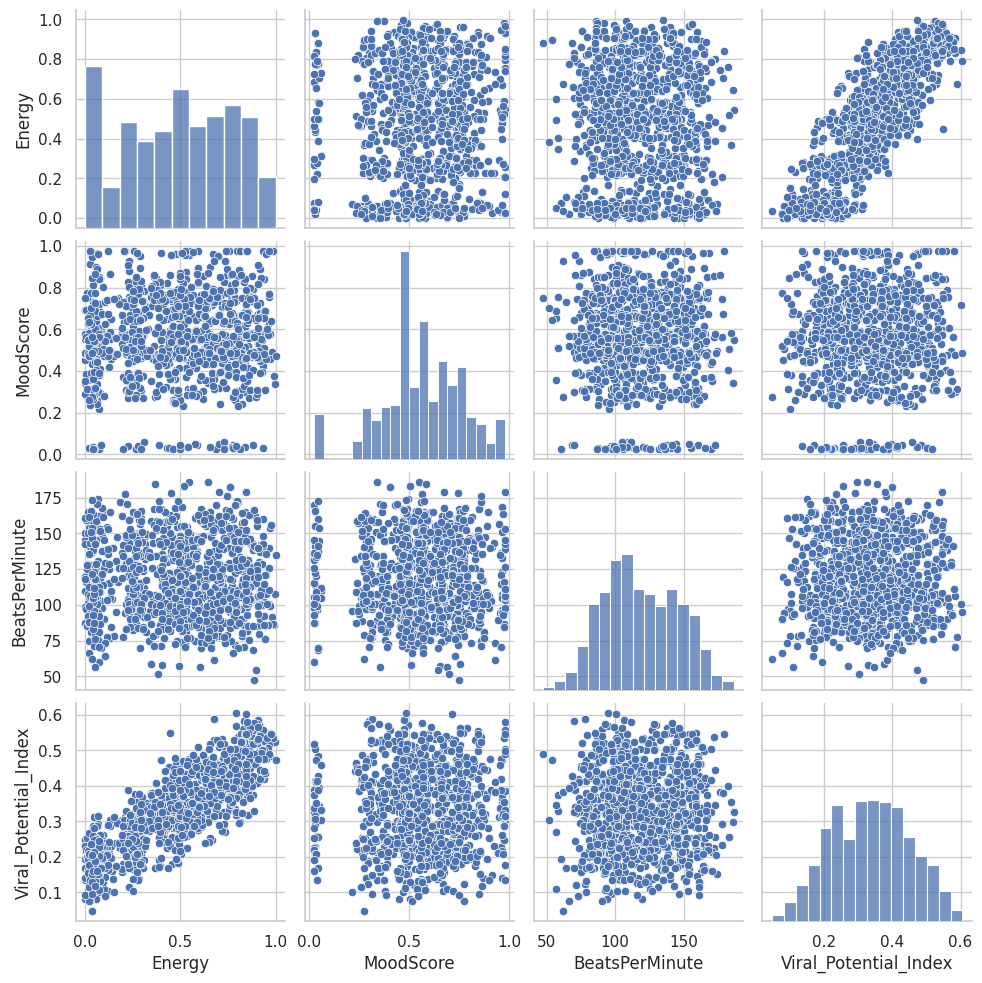

In [20]:
sns.pairplot(df.sample(1000), vars=["Energy", "MoodScore", "BeatsPerMinute", "Viral_Potential_Index"])
plt.show()

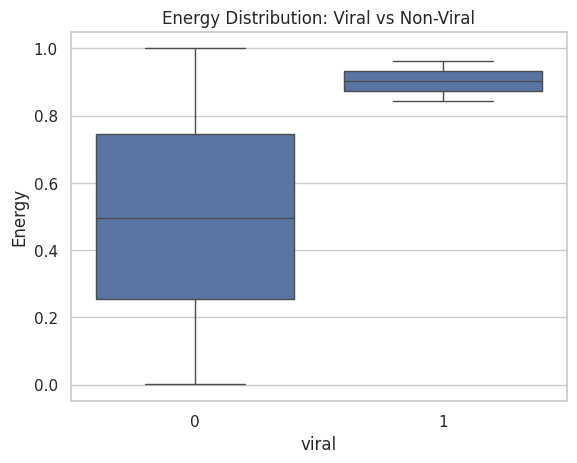

In [21]:
df["viral"] = (df["Viral_Potential_Index"] > 0.7).astype(int)

sns.boxplot(x="viral", y="Energy", data=df)
plt.title("Energy Distribution: Viral vs Non-Viral")
plt.show()

In [22]:
X = df.drop(columns=["Viral_Potential_Index", "viral"])
y = df["Viral_Potential_Index"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, max_depth=6)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = rmse

results

{'Linear': np.float64(0.0195355271067267),
 'RandomForest': np.float64(0.0046777676030318694),
 'XGBoost': np.float64(0.004406249310225271)}

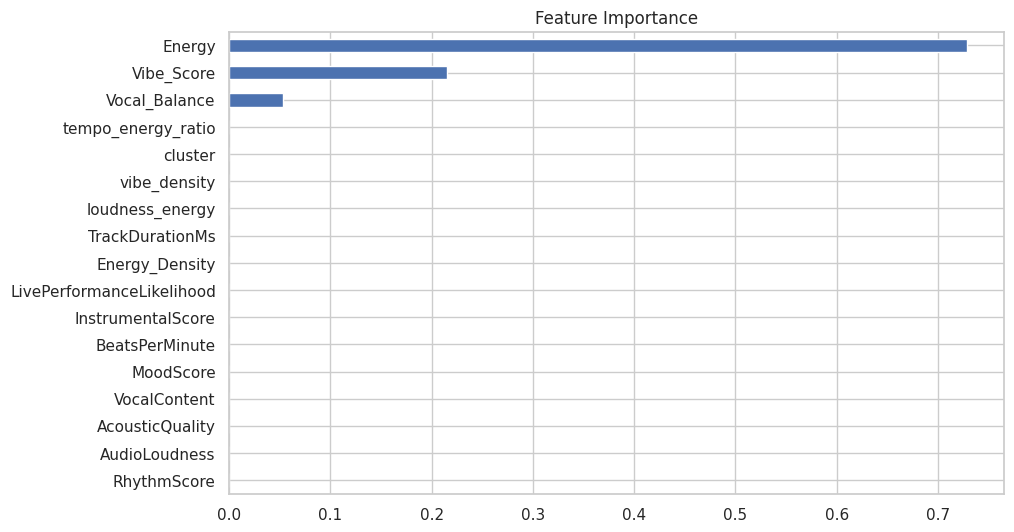

In [23]:
best_model = xgb.XGBRegressor(n_estimators=300, max_depth=6)
best_model.fit(X_train, y_train)

importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance")
plt.show()

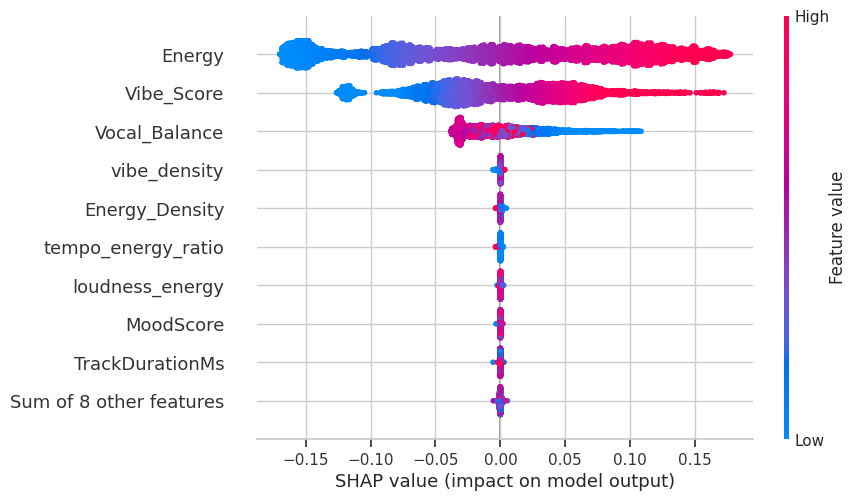

In [24]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

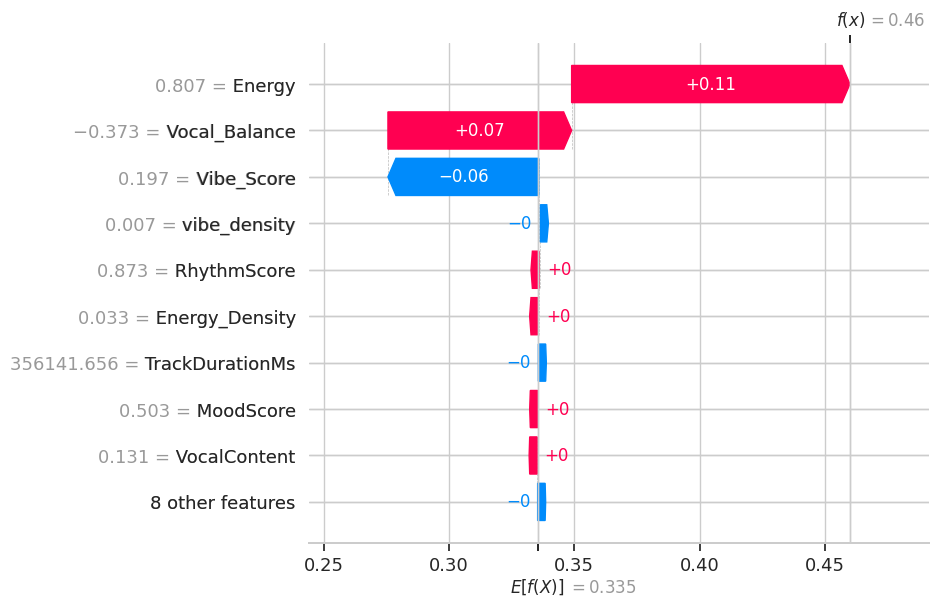

In [25]:
shap.plots.waterfall(shap_values[0])

In [26]:
y_class = df["viral"]

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 1.0


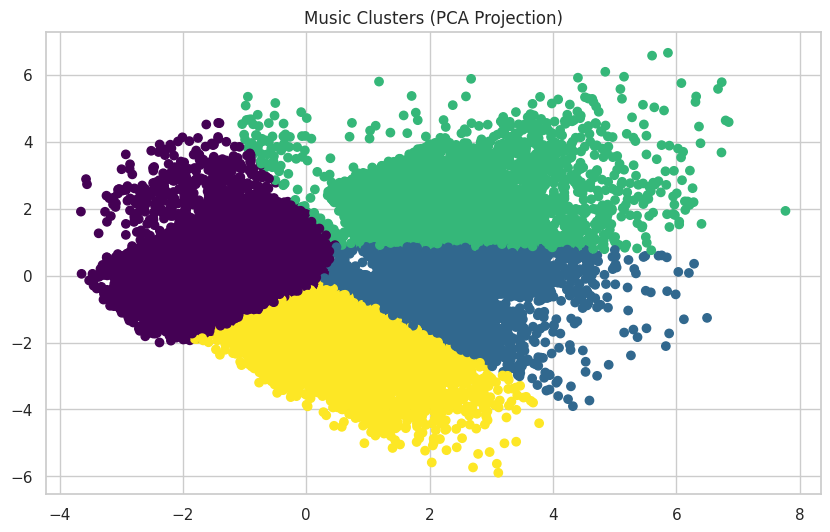

In [27]:
scaler = StandardScaler()
scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(pca_data)

plt.figure(figsize=(10,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap="viridis")
plt.title("Music Clusters (PCA Projection)")
plt.show()

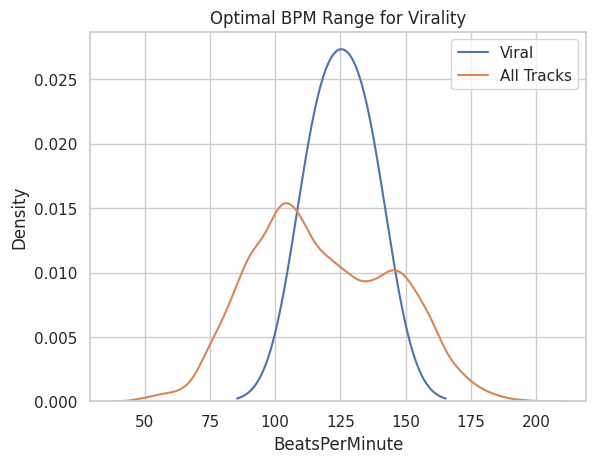

In [28]:
viral_df = df[df["viral"] == 1]

sns.kdeplot(viral_df["BeatsPerMinute"], label="Viral")
sns.kdeplot(df["BeatsPerMinute"], label="All Tracks")
plt.legend()
plt.title("Optimal BPM Range for Virality")
plt.show()

In [29]:
viral_means = viral_df.mean()
nonviral_means = df[df["viral"] == 0].mean()

comparison = pd.DataFrame({
    "Viral": viral_means,
    "Non-Viral": nonviral_means
})

comparison.loc[["Energy", "MoodScore", "BeatsPerMinute", "Vibe_Score"]]

,Viral,Non-Viral
Energy,0.903178,0.484989
MoodScore,0.265662,0.551685
BeatsPerMinute,125.371395,118.236127
Vibe_Score,0.915525,0.363712


In [30]:
def predict_virality(input_dict):
    input_df = pd.DataFrame([input_dict])
    return best_model.predict(input_df)[0]

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

# Prepare data
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1,1)

class ViralNet(nn.Module):
    def __init__(self, input_dim):
        super(ViralNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.net(x)

model_nn = ViralNet(X.shape[1])
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

# Training loop
for epoch in range(50):
    optimizer.zero_grad()
    preds = model_nn(X_tensor)
    loss = loss_fn(preds, y_tensor)
    loss.backward()
    optimizer.step()

print("Final Loss:", loss.item())

Final Loss: 0.012143056839704514


In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [4, 6, 8],
    "n_estimators": [100, 300],
    "learning_rate": [0.01, 0.05]
}

grid = GridSearchCV(
    xgb.XGBRegressor(),
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100}


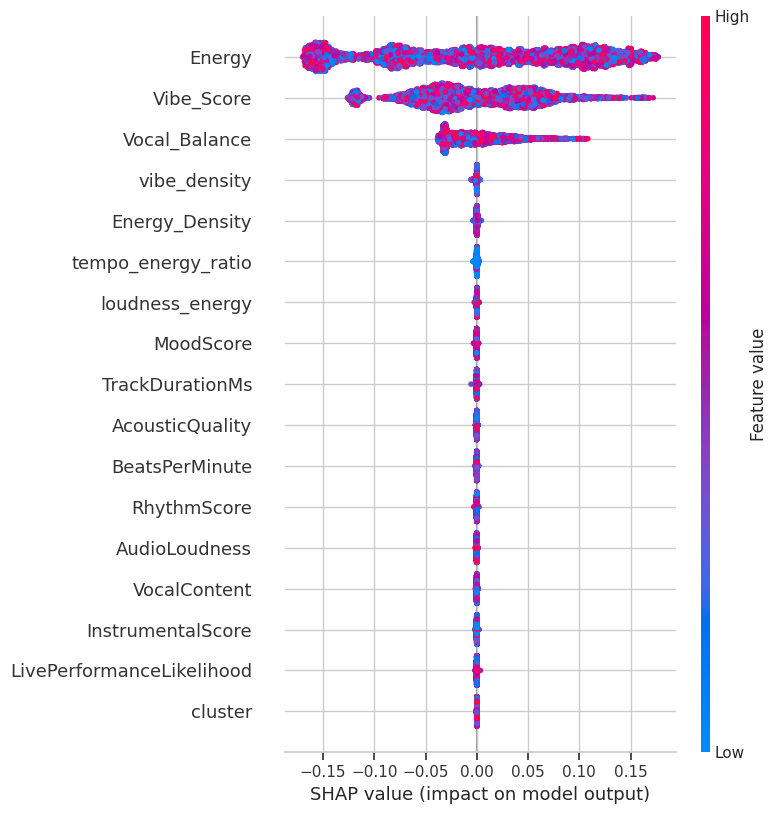

In [33]:
shap.summary_plot(shap_values, X_test)

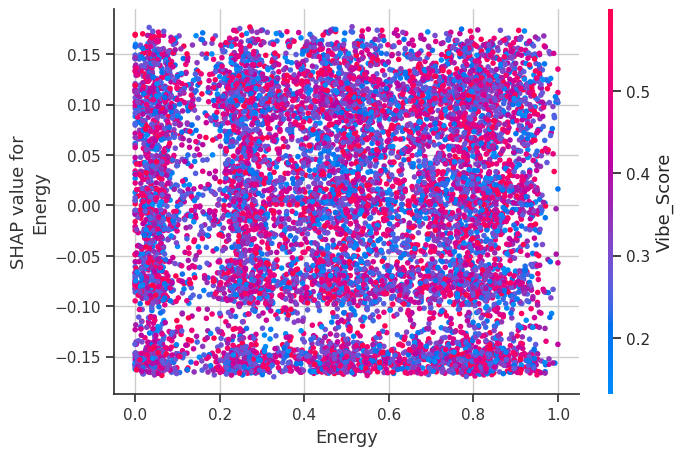

In [34]:
shap.dependence_plot("Energy", shap_values.values, X_test)

In [35]:
def simulate_track_variation(base_track, feature, values):
    results = []

    for v in values:
        modified = base_track.copy()
        modified[feature] = v
        
        pred = best_model.predict(pd.DataFrame([modified]))[0]
        results.append((v, pred))
    
    return pd.DataFrame(results, columns=[feature, "Predicted_Virality"])

<Axes: title={'center': 'BPM vs Virality'}, xlabel='BeatsPerMinute'>

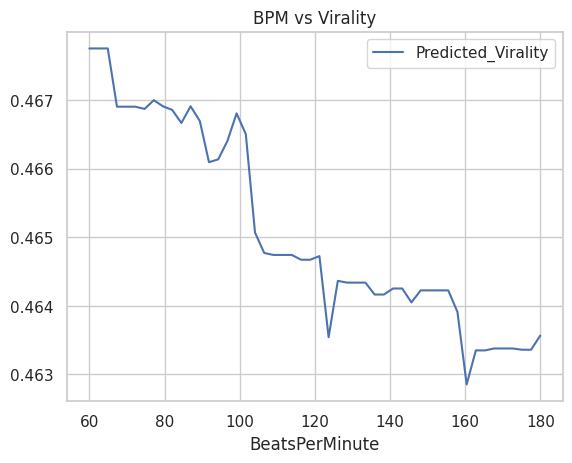

In [36]:
sample = X.iloc[0].to_dict()

sim = simulate_track_variation(
    sample,
    "BeatsPerMinute",
    np.linspace(60, 180, 50)
)

sim.plot(x="BeatsPerMinute", y="Predicted_Virality", title="BPM vs Virality")

In [37]:
best_score = 0
best_config = None

for _ in range(5000):
    sample = {
        col: np.random.uniform(df[col].min(), df[col].max())
        for col in X.columns
    }
    
    pred = best_model.predict(pd.DataFrame([sample]))[0]
    
    if pred > best_score:
        best_score = pred
        best_config = sample

print("🔥 Best Possible Track:")
print(best_config)
print("Predicted Virality:", best_score)

🔥 Best Possible Track:
{'RhythmScore': 0.821229183771685, 'AudioLoudness': -5.693064613156352, 'VocalContent': 0.09762267653756124, 'AcousticQuality': 0.7323529849161498, 'InstrumentalScore': 0.2532129960449081, 'LivePerformanceLikelihood': 0.2571507534938317, 'MoodScore': 0.26078578468339186, 'TrackDurationMs': 385063.4342078321, 'Energy': 0.8468202534364725, 'BeatsPerMinute': 179.98707664476655, 'Vocal_Balance': -0.4205310554503645, 'Energy_Density': 0.012561263230024948, 'Vibe_Score': 0.8303392231883336, 'tempo_energy_ratio': 541472.1446880796, 'loudness_energy': -8.98115350098231, 'vibe_density': 0.2614147873326697, 'cluster': 0.7273683289558183}
Predicted Virality: 0.7352308


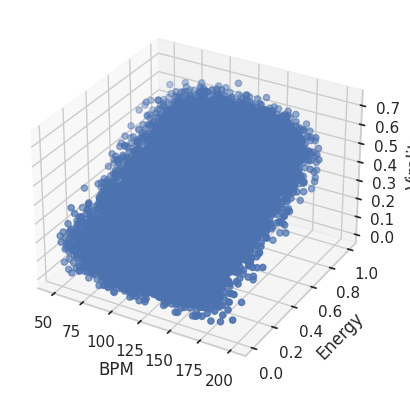

In [38]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["BeatsPerMinute"],
    df["Energy"],
    df["Viral_Potential_Index"]
)

ax.set_xlabel("BPM")
ax.set_ylabel("Energy")
ax.set_zlabel("Virality")

plt.show()